In [1]:
import os
import geopandas as gpd
import requests
import pandas as pd
import folium
import matplotlib.pyplot as plt

Columns for Demografi : ['geometry', 'fid', 'ID_PROV', 'PROVINSI', 'ID_KABKOT', 'KABKOT', 'ID_KEC', 'KECAMATAN', 'ID_DESA', 'DESA', 'JUMLAH PENDUDUK', 'JUMLAH KK', 'LUAS WILAYAH (KM²)', 'KEPADATAN PENDUDUK', 'PERPINDAHAN PENDUDUK', 'JUMLAH MENINGGAL', 'PERUBAHAN DATA', 'JUMLAH WAJIB KTP', 'JUMLAH REKAM WAJIB KTP', 'ISLAM', 'KRISTEN', 'KATHOLIK', 'HINDU', 'BUDDHA', 'KONGHUCU', 'KEPERCAYAAN TERHADAP TUHAN YME', 'LAKI-LAKI', 'PEREMPUAN', 'BELUM KAWIN', 'KAWIN', 'CERAI HIDUP', 'CERAI MATI', 'USIA 0-4', 'USIA 5-9', 'USIA 10-14', 'USIA 15-19', 'USIA 20-24', 'USIA 25-29', 'USIA 30-34', 'USIA 35-39', 'USIA 40-44', 'USIA 45-49', 'USIA 50-54', 'USIA 55-59', 'USIA 60-64', 'USIA 65-69', 'USIA 70-74', 'USIA 75 TAHUN KE ATAS', 'LAHIR TAHUN 2020', 'LAHIR SEBELUM TAHUN 2020', 'LAHIR TAHUN 2021', 'LAHIR SEBELUM TAHUN 2021', 'LAHIR TAHUN 2022', 'LAHIR SEBELUM TAHUN 2022', 'LAHIR TAHUN 2023', 'LAHIR SEBELUM TAHUN 2023', 'LAHIR TAHUN 2024', 'LAHIR SEBELUM 2024', 'PERTUMBUHAN PENDUDUK TAHUN 2020 (%)', 'PER

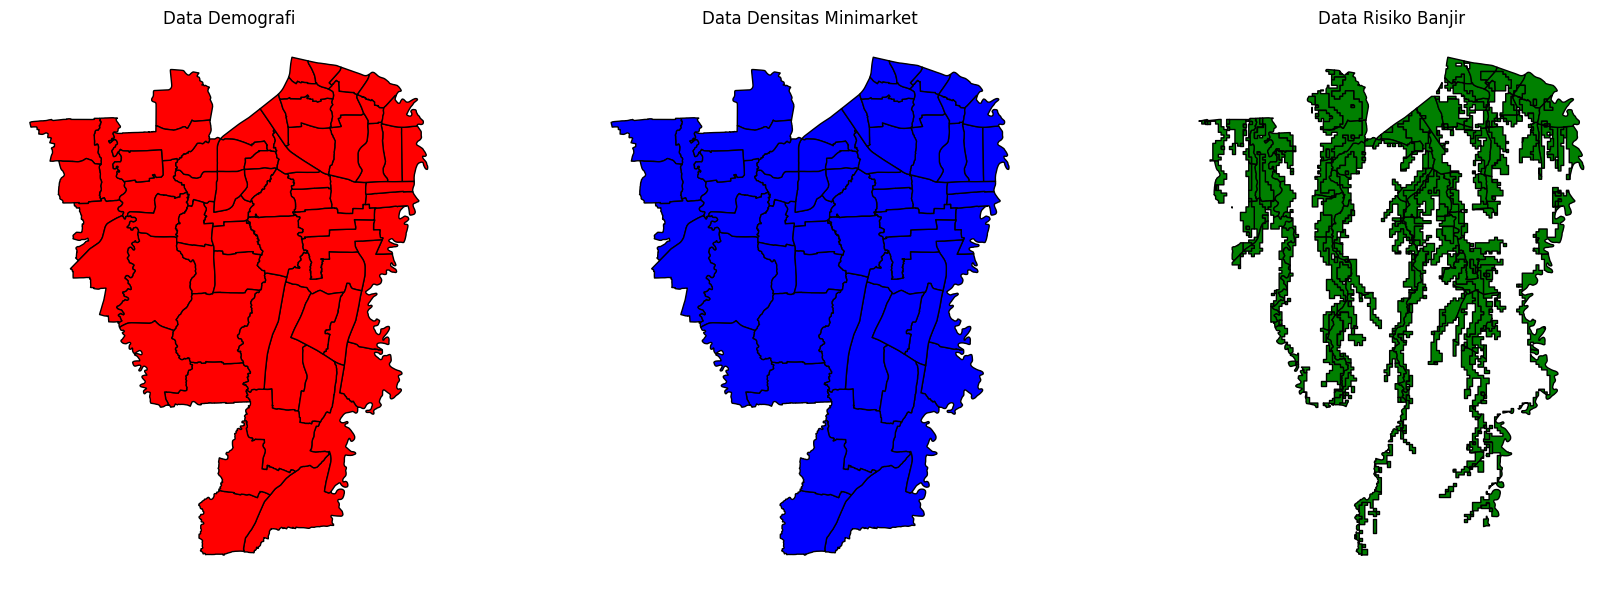

In [10]:
urls = {
    "Demografi":"https://geoserver.mapid.io/layers_new/get_layer?api_key=ba3fadef689b4d6c95ca36d0f5d76bba&layer_id=68af37b54a3bb7db31356f35&project_id=68af04ceabcfc44262fbabcf&limit=10000",
    "Densitas Minimarket":"https://geoserver.mapid.io/layers_new/get_layer?api_key=ba3fadef689b4d6c95ca36d0f5d76bba&layer_id=68af3431abcfc44262fbdf4f&project_id=68af04ceabcfc44262fbabcf&limit=10000",
    "Risiko Banjir":"https://geoserver.mapid.io/layers_new/get_layer?api_key=ba3fadef689b4d6c95ca36d0f5d76bba&layer_id=68af0548b2fcc5561a32f98c&project_id=68af04ceabcfc44262fbabcf&limit=10000"
}

#menambahkan kolom skor
def get_data(url, layer_name):
    response = requests.get(url)
    if response.status_code == 200:
        geojson_data = response.json()
        gdf = gpd.GeoDataFrame.from_features(geojson_data['features'])

        print("Columns for", layer_name, ":", gdf.columns.tolist())  # 🔍 debug check

        # menambahkan kolom skor
        if layer_name == "Demografi":
            gdf["SKOR_DEMOGRAFI"] = (
                gdf["Kelas_KP"].astype(str).str.upper()
                .map({"RENDAH": 1, "SEDANG": 2, "TINGGI": 3})
                .fillna(0)
            )

        elif layer_name == "Densitas Minimarket":
            gdf["SKOR_DENSITAS"] = (
                gdf["Kelas_Densitas"].astype(str).str.upper()
                .map({"RENDAH": 3, "SEDANG": 2, "TINGGI": 1})
                .fillna(0)
            )

        elif layer_name == "Risiko Banjir":
            gdf["SKOR_BANJIR"] = (
                gdf["KELAS_RISIKO"].astype(str).str.upper()
                .map({"RENDAH": 3, "SEDANG": 2, "TINGGI": 1})
                .fillna(0)
            )

        return gdf
    else:
        print(f"Failed to fetch {layer_name}, status: {response.status_code}")
        return gpd.GeoDataFrame()

#Mengambil Data Dari Semua Layer

gdf_demografi = get_data(urls["Demografi"], "Demografi")
gdf_densitas = get_data(urls["Densitas Minimarket"], "Densitas Minimarket")
gdf_banjir = get_data(urls["Risiko Banjir"], "Risiko Banjir")

#visualisasi data variable
def visualize_data(gdfs):
    fig, axes = plt.subplots(1, len(gdfs), figsize = (18, 6))
    color_map = ['red', 'blue', 'green']
    for ax, (name, gdf), color in zip (axes, gdfs.items(), color_map):
            gdf.plot(ax=ax, color=color, edgecolor='black')
            ax.set_title(name)
            ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    
# Menampilkan visualisasi dari ketiga GeoDataFrame
visualize_data({"Data Demografi": gdf_demografi, 
                "Data Densitas Minimarket":gdf_densitas,
                "Data Risiko Banjir": gdf_banjir})


In [17]:
import geopandas as gpd
import pandas as pd

# ==========================================================
# Fungsi bantu
# ==========================================================
# Hanya ambil Polygon/MultiPolygon
def filter_polygon(gdf):
    if gdf.empty:
        return gdf
    return gdf[gdf.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()

# Perbaiki geometri invalid
def fix_geometry(gdf):
    if gdf.empty:
        return gdf
    gdf = gdf[gdf.is_valid].copy()
    gdf['geometry'] = gdf['geometry'].apply(
        lambda x: x if x.is_valid else x.buffer(0)
    )
    return gdf

# Overlay tapi hanya simpan polygon
def overlay_polygon(df1, df2, how="intersection"):
    result = gpd.overlay(df1, df2, how=how, keep_geom_type=False)
    result = result.explode(index_parts=False, ignore_index=True)
    result = result[result.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
    result = fix_geometry(result)
    return result

# ==========================================================
# Preprocessing awal
# ==========================================================
# Pastikan tidak ada nilai NULL pada skor
gdf_demografi['SKOR_DEMOGRAFI'] = gdf_demografi['SKOR_DEMOGRAFI'].fillna(0)
gdf_densitas['SKOR_DENSITAS']   = gdf_densitas['SKOR_DENSITAS'].fillna(0)
gdf_banjir['SKOR_BANJIR']       = gdf_banjir['SKOR_BANJIR'].fillna(0)

# Filter hanya polygon/multipolygon
gdf_demografi = fix_geometry(filter_polygon(gdf_demografi))
gdf_densitas  = fix_geometry(filter_polygon(gdf_densitas))
gdf_banjir    = fix_geometry(filter_polygon(gdf_banjir))

# ==========================================================
# Overlay bertahap
# ==========================================================
intersection_gdf = gdf_demografi.copy()

if not gdf_densitas.empty:
    intersection_gdf = overlay_polygon(intersection_gdf, gdf_densitas)

if not gdf_banjir.empty:
    intersection_gdf = overlay_polygon(intersection_gdf, gdf_banjir)

# ==========================================================
# Hitung skor & klasifikasi
# ==========================================================
intersection_gdf['SKOR_TOTAL'] = (
    intersection_gdf.get('SKOR_DEMOGRAFI', 0) +
    intersection_gdf.get('SKOR_DENSITAS', 0) +
    intersection_gdf.get('SKOR_BANJIR', 0)
)

intersection_gdf['KESESUAIAN'] = pd.cut(
    intersection_gdf['SKOR_TOTAL'],
    bins=[0, 2, 5, 7, 9],   # sesuaikan range
    labels=['SANGAT RENDAH','RENDAH', 'SEDANG', 'TINGGI'],
    include_lowest=True
)

# ==========================================================
# Cek hasil
# ==========================================================
print(intersection_gdf[['SKOR_DEMOGRAFI', 'SKOR_DENSITAS',
                        'SKOR_BANJIR', 'SKOR_TOTAL', 'KESESUAIAN']].head(50))


      SKOR_DEMOGRAFI  SKOR_DENSITAS  SKOR_BANJIR  SKOR_TOTAL KESESUAIAN
0                  2              3            1           6     SEDANG
938                2              3            2           7     SEDANG
965                2              3            2           7     SEDANG
966                2              3            2           7     SEDANG
967                2              3            2           7     SEDANG
968                3              1            1           5     RENDAH
1087               3              1            2           6     SEDANG
1092               3              1            2           6     SEDANG
1110               3              1            2           6     SEDANG
1187               3              1            2           6     SEDANG
1189               3              1            1           5     RENDAH
1271               2              2            1           5     RENDAH
1272               2              2            1           5    

In [ ]:
#Karena error, jadi ada bantuan dari ChatGPT

#dimulai dari sini

import geopandas as gpd
import pandas as pd
from shapely.geometry import Polygon, MultiPolygon

# optional: try to use shapely.make_valid jika tersedia (lebih andal daripada buffer(0))
try:
    from shapely.validation import make_valid as _shapely_make_valid
except Exception:
    _shapely_make_valid = None

# -----------------------
# Helper functions
# -----------------------
def safe_make_valid(geom):
    """Coba beberapa metode untuk memperbaiki geometry; fallback ke buffer(0)."""
    if geom is None:
        return geom
    try:
        # shapely.validation.make_valid (jika ada)
        if _shapely_make_valid is not None:
            fixed = _shapely_make_valid(geom)
            if fixed is not None:
                return fixed
        # objek geometry mungkin punya method make_valid (shapely >= 2)
        if hasattr(geom, "make_valid"):
            return geom.make_valid()
    except Exception:
        pass
    try:
        return geom.buffer(0)
    except Exception:
        return geom

def fix_geometry(gdf):
    """Perbaiki geometri yang tidak valid dan buang yang kosong/null."""
    if gdf is None or gdf.empty:
        return gdf
    gdf = gdf.copy()
    # Pastikan ada kolom geometry
    gdf = gdf[~gdf.geometry.isnull()].copy()
    # Perbaiki geometri yang tidak valid
    gdf['geometry'] = gdf['geometry'].apply(lambda x: safe_make_valid(x) if not getattr(x, 'is_valid', True) else x)
    # Buang geometry kosong/None
    gdf = gdf[gdf.geometry.notnull() & (~gdf.geometry.is_empty)].copy()
    return gdf

def filter_polygon(gdf):
    """Ambil hanya Polygon / MultiPolygon dari GeoDataFrame."""
    if gdf is None or gdf.empty:
        return gdf
    return gdf[gdf.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()

def overlay_polygon(df1, df2, how="intersection"):
    """
    Lakukan overlay tetapi:
    - pecah multipart (explode)
    - buang hasil yang bukan Polygon/MultiPolygon (karena overlay bisa menghasilkan LineString/Point)
    - perbaiki geometri hasilnya
    """
    if df1 is None or df2 is None:
        return gpd.GeoDataFrame(columns=df1.columns if df1 is not None else [], geometry=[])
    if df1.empty or df2.empty:
        return gpd.GeoDataFrame(columns=df1.columns, geometry=[])

    result = gpd.overlay(df1, df2, how=how, keep_geom_type=False)

    # Explode (compatibilitas geopandas versi lama/baru)
    try:
        result = result.explode(index_parts=False, ignore_index=True)
    except TypeError:
        # fallback untuk geopandas lama yang tidak punya index_parts arg
        result = result.explode(ignore_index=True)

    # Hanya polygon
    result = result[result.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
    result = fix_geometry(result)
    return result

##Sampai Sini. Namun di bawah juga ada beberapa bantuan dari ChatGPT. karean error

# Pastikan kolom skor ada; jika tidak ada, buat dengan 0
if 'SKOR_DEMOGRAFI' not in gdf_demografi.columns:
    gdf_demografi['SKOR_DEMOGRAFI'] = 0
if 'SKOR_DENSITAS' not in gdf_densitas.columns:
    gdf_densitas['SKOR_DENSITAS'] = 0
if 'SKOR_BANJIR' not in gdf_banjir.columns:
    gdf_banjir['SKOR_BANJIR'] = 0

# Fill NA pada masing-masing score
gdf_demografi['SKOR_DEMOGRAFI'] = gdf_demografi['SKOR_DEMOGRAFI'].fillna(0)
gdf_densitas['SKOR_DENSITAS']   = gdf_densitas['SKOR_DENSITAS'].fillna(0)
gdf_banjir['SKOR_BANJIR']       = gdf_banjir['SKOR_BANJIR'].fillna(0)

# Filter only polygons & fix geometry awal
gdf_demografi = fix_geometry(filter_polygon(gdf_demografi))
gdf_densitas  = fix_geometry(filter_polygon(gdf_densitas))
gdf_banjir    = fix_geometry(filter_polygon(gdf_banjir))

# Intersection bertahap (hanya menyimpan polygon hasil overlay)
intersection_gdf = gdf_demografi.copy()

if not gdf_densitas.empty:
    intersection_gdf = overlay_polygon(intersection_gdf, gdf_densitas, how="intersection")

if not gdf_banjir.empty:
    intersection_gdf = overlay_polygon(intersection_gdf, gdf_banjir, how="intersection")

# Jika kosong, hentikan lebih awal
if intersection_gdf is None or intersection_gdf.empty:
    print("Hasil intersection kosong — tidak ada area overlap di semua layer.")
else:
    # Pastikan kolom skor ada dan tidak ada NA setelah overlay
    intersection_gdf['SKOR_DEMOGRAFI'] = intersection_gdf.get('SKOR_DEMOGRAFI', 0).fillna(0)
    intersection_gdf['SKOR_DENSITAS']  = intersection_gdf.get('SKOR_DENSITAS', 0).fillna(0)
    intersection_gdf['SKOR_BANJIR']    = intersection_gdf.get('SKOR_BANJIR', 0).fillna(0)

    # Hitung skor total
    intersection_gdf['SKOR_TOTAL'] = (
        intersection_gdf['SKOR_DEMOGRAFI'].astype(float) +
        intersection_gdf['SKOR_DENSITAS'].astype(float) +
        intersection_gdf['SKOR_BANJIR'].astype(float)
    )

    # Klasifikasi — gunakan bins yang aman (termasuk kemungkinan 0)
    bins = [-1, 5, 7, 9]   # ubah nilai ini sesuai kebutuhan
    labels = ['RENDAH', 'SEDANG', 'TINGGI']
    intersection_gdf['KESESUAIAN'] = pd.cut(
        intersection_gdf['SKOR_TOTAL'],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    # Tampilkan ringkasan
    print(intersection_gdf[['SKOR_DEMOGRAFI', 'SKOR_DENSITAS', 'SKOR_BANJIR', 'SKOR_TOTAL', 'KESESUAIAN']].head(10))
    print("\nDistribusi KESESUAIAN:")
    print(intersection_gdf['KESESUAIAN'].value_counts(dropna=False))


      SKOR_DEMOGRAFI  SKOR_DENSITAS  SKOR_BANJIR  SKOR_TOTAL KESESUAIAN
0                  2              3            1         6.0     SEDANG
938                2              3            2         7.0     SEDANG
965                2              3            2         7.0     SEDANG
966                2              3            2         7.0     SEDANG
967                2              3            2         7.0     SEDANG
968                3              1            1         5.0     RENDAH
1087               3              1            2         6.0     SEDANG
1092               3              1            2         6.0     SEDANG
1110               3              1            2         6.0     SEDANG
1187               3              1            2         6.0     SEDANG

Distribusi KESESUAIAN:
KESESUAIAN
SEDANG    392
RENDAH    234
TINGGI     10
Name: count, dtype: int64


In [ ]:
##Mencoba dengan varian lain menggunakan bantuan ChatGPT

import geopandas as gpd
import pandas as pd

# -------------------------------
# 1. Fungsi bantu untuk bersihkan geometri
# -------------------------------
def ensure_polygons(gdf):
    """Pastikan hanya Polygon/MultiPolygon, buang lainnya, dan perbaiki geometri"""
    if gdf.empty:
        return gdf
    gdf = gdf[gdf.geom_type.isin(["Polygon", "MultiPolygon"])].copy()  # hanya polygon
    gdf["geometry"] = gdf["geometry"].buffer(0)  # perbaiki invalid
    return gdf

# -------------------------------
# 2. Perbaikan awal (isi nilai NULL & pastikan geometri polygon)
# -------------------------------
gdf_demografi["SKOR_DEMOGRAFI"] = gdf_demografi["SKOR_DEMOGRAFI"].fillna(0)
gdf_densitas["SKOR_DENSITAS"]   = gdf_densitas["SKOR_DENSITAS"].fillna(0)
gdf_banjir["SKOR_BANJIR"]       = gdf_banjir["SKOR_BANJIR"].fillna(0)

gdf_demografi = ensure_polygons(gdf_demografi)
gdf_densitas  = ensure_polygons(gdf_densitas)
gdf_banjir    = ensure_polygons(gdf_banjir)

# -------------------------------
# 3. Intersection overlay
# -------------------------------
intersection_gdf = gdf_demografi
if not gdf_densitas.empty:
    intersection_gdf = gpd.overlay(intersection_gdf, gdf_densitas, how="intersection")
if not gdf_banjir.empty:
    intersection_gdf = gpd.overlay(intersection_gdf, gdf_banjir, how="intersection")

# -------------------------------
# 4. Perbaiki hasil intersection
# -------------------------------
# Buang geometry invalid
intersection_gdf = intersection_gdf[intersection_gdf.is_valid].copy()
# Isi NULL yang mungkin muncul lagi setelah overlay
intersection_gdf["SKOR_DEMOGRAFI"] = intersection_gdf["SKOR_DEMOGRAFI"].fillna(0)
intersection_gdf["SKOR_DENSITAS"]  = intersection_gdf["SKOR_DENSITAS"].fillna(0)
intersection_gdf["SKOR_BANJIR"]    = intersection_gdf["SKOR_BANJIR"].fillna(0)

# -------------------------------
# 5. Hitung skor & klasifikasi
# -------------------------------
intersection_gdf["SKOR_TOTAL"] = (
    intersection_gdf["SKOR_DEMOGRAFI"] +
    intersection_gdf["SKOR_DENSITAS"] +
    intersection_gdf["SKOR_BANJIR"]
)

intersection_gdf["KESESUAIAN"] = pd.cut(
    intersection_gdf["SKOR_TOTAL"],
    bins=[2, 5, 7, 9],              # interval skor
    labels=["RENDAH", "SEDANG", "TINGGI"],
    include_lowest=True
)

# -------------------------------
# 6. Cek hasil
# -------------------------------
print(intersection_gdf[[
    "SKOR_DEMOGRAFI",
    "SKOR_DENSITAS",
    "SKOR_BANJIR",
    "SKOR_TOTAL",
    "KESESUAIAN"
]].head(25))


c:\Users\mfata\Documents\Pribadi\Pelatihan\MAPID\WEBGIS\Day6\TaskDay6\TASK_DAY6\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 328 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


    SKOR_DEMOGRAFI  SKOR_DENSITAS  SKOR_BANJIR  SKOR_TOTAL KESESUAIAN
0                2              3            1           6     SEDANG
1                2              3            2           7     SEDANG
2                2              3            2           7     SEDANG
3                2              3            2           7     SEDANG
4                2              3            2           7     SEDANG
5                3              1            1           5     RENDAH
6                3              1            2           6     SEDANG
7                3              1            2           6     SEDANG
8                3              1            2           6     SEDANG
9                3              1            2           6     SEDANG
10               3              1            1           5     RENDAH
11               2              2            1           5     RENDAH
12               2              2            2           6     SEDANG
13               2  

c:\Users\mfata\Documents\Pribadi\Pelatihan\MAPID\WEBGIS\Day6\TaskDay6\TASK_DAY6\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 514 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [32]:
import os

# Folder output
output_dir = r"C:\Users\mfata\Documents\Pribadi\Pelatihan\MAPID\WEBGIS\Day6\TaskDay6"
os.makedirs(output_dir, exist_ok=True)

# Filter hanya Polygon/MultiPolygon
intersection_gdf_polygons = intersection_gdf[intersection_gdf.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()

# Perbaiki geometri invalid
intersection_gdf_polygons["geometry"] = intersection_gdf_polygons["geometry"].buffer(0)

# Simpan masing-masing layer ke GeoJSON
gdf_demografi.to_file(os.path.join(output_dir, "demografi.geojson"), driver="GeoJSON")
gdf_densitas.to_file(os.path.join(output_dir, "densitas_minimarket.geojson"), driver="GeoJSON")
gdf_banjir.to_file(os.path.join(output_dir, "risiko_banjir.geojson"), driver="GeoJSON")

# Simpan hasil intersection
intersection_gdf_polygons.to_file(os.path.join(output_dir, "Hasil_Intersect.geojson"), driver="GeoJSON")

print(f"Data berhasil disimpan di: {output_dir}")
print("Semua file geojson telah berhasil disimpan.")


c:\Users\mfata\Documents\Pribadi\Pelatihan\MAPID\WEBGIS\Day6\TaskDay6\TASK_DAY6\Lib\site-packages\pyogrio\geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
c:\Users\mfata\Documents\Pribadi\Pelatihan\MAPID\WEBGIS\Day6\TaskDay6\TASK_DAY6\Lib\site-packages\pyogrio\geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
c:\Users\mfata\Documents\Pribadi\Pelatihan\MAPID\WEBGIS\Day6\TaskDay6\TASK_DAY6\Lib\site-packages\pyogrio\geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
c:\Users\mfata\Documents\Pribadi\Pelatihan\MAPID\WEBGIS\Day6\TaskDay6\TASK_DAY6\Lib\site-packages\pyogrio\geopandas.py:710: UserWarning: 'crs' was not provided.  The output da

Data berhasil disimpan di: C:\Users\mfata\Documents\Pribadi\Pelatihan\MAPID\WEBGIS\Day6\TaskDay6
Semua file geojson telah berhasil disimpan.


Banyak dari scripot nya dibantu perbaiki oleh CHatGPT. Karena error dan juga tidak bisa menarik data dari API. Sehingga ada beberapa langkah yang harus saya perbaiki dan cari jalan keluarnya